## Human In the Loop

In [1]:
import os
from langchain.chat_models import init_chat_model

llm= init_chat_model("openai/gpt-oss-120b",model_provider="groq")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x10fd81940>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10fd823c0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [5]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder= StateGraph(State)

@tool
def human_assistance(query:str)-> str: 
    """Request assistance from a human."""
    human_response= interrupt({"query":query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools= [tool,human_assistance]
llm_with_tools= llm.bind_tools(tools)


def chatbot(state: State):
    message= llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution, 
    # we disable parllel tool calling to avoid repeating any 
    # tool invocations when we resume. 

    return {"messages":[message]}

graph_builder.add_node("chatbot",chatbot)

tool_node= ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)

graph_builder.add_conditional_edges(
    "chatbot", 
     tools_condition
)

graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")

In [6]:
memory= MemorySaver()
graph= graph_builder.compile(checkpointer=memory)

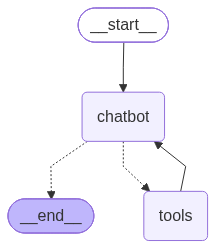

In [7]:
from IPython.display import Image, display

try: 
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    #This required some extraa dependencies and is optional
    pass

In [9]:
user_input= "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me? "
config= {"configurable": {"thread_id":"1"}}

events= graph.stream(
        {"messages": user_input}, 
        config,
        stream_mode= "values",)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me? 
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_27facb47-18d9-4030-858a-50c430190d8e)
 Call ID: fc_27facb47-18d9-4030-858a-50c430190d8e
  Args:
    query: User requests expert guidance and assistance for building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_27facb47-18d9-4030-858a-50c430190d8e)
 Call ID: fc_27facb47-18d9-4030-858a-50c430190d8e
  Args:
    query: User requests expert guidance and assistance for building an AI agent.


In [10]:
human_response= (
    "We, the experts are here to help! we'd recommend you check out LangGraph to build your agent."
    "It's much more reliable and extensible than simple autonomous agents."
)

human_command= Command(resume={"data": human_response})

events = graph.stream(human_command,config, stream_mode='values')

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_27facb47-18d9-4030-858a-50c430190d8e)
 Call ID: fc_27facb47-18d9-4030-858a-50c430190d8e
  Args:
    query: User requests expert guidance and assistance for building an AI agent.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! we'd recommend you check out LangGraph to build your agent.It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

Absolutely! Building a robust AI agent can be a rewarding (and sometimes complex) project, but with the right roadmap and tools you’ll be able to move forward confidently. Below is a practical, step‑by‑step guide that covers the major decisions you’ll need to make, the most common building blocks, and some concrete resources to get you started right away